# Stage 10b — Time Series & Classification Baseline Modeling

This notebook demonstrates lag and rolling feature engineering without data leakage, a time-aware train-test split, pipeline construction with Scikit-Learn, and model evaluation across next-step directional classification and return forecasting.

In [1]:
# Setup & Imports

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Styling and reproducibility
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)
np.random.seed(7)

In [2]:
# Synthetic Time-Series Data Generation

# Generate synthetic price series with structural regime shifts and sudden jumps
n = 500
dates = pd.bdate_range("2021-01-01", periods=n)
mu = np.where(np.arange(n) < n // 2, 0.0003, -0.0001)
sigma = np.where(np.arange(n) < n // 2, 0.01, 0.015)
eps = np.random.normal(mu, sigma)

# Add random market jumps
jumps = np.zeros(n)
jump_days = np.random.choice(np.arange(20, n - 20), size=5, replace=False)
jumps[jump_days] = np.random.normal(0, 0.05, size=len(jump_days))

rets = eps + jumps
price = 100 * np.exp(np.cumsum(rets))

df = pd.DataFrame({"price": price}, index=dates)
df["ret"] = df["price"].pct_change().fillna(0.0)
df["log_ret"] = np.log1p(df["ret"])

df.head()

,price,ret,log_ret
2021-01-01,101.735412,0.000000,0.000000
2021-01-04,101.292875,-0.004350,-0.004359
2021-01-05,101.356527,0.000628,0.000628
2021-01-06,101.800950,0.004385,0.004375
2021-01-07,101.031283,-0.007561,-0.007589


In [3]:
# Feature Engineering (Preventing Data Leakage)

# Feature 1: Lagged return (t-1)
df["lag_1"] = df["ret"].shift(1)

# Feature 2: 5-day rolling mean return (shifted by 1 to exclude current day)
df["roll_mean_5"] = df["ret"].rolling(5).mean().shift(1)

# Feature 3: 20-day rolling volatility / standard deviation (shifted by 1)
df["roll_vol_20"] = df["ret"].rolling(20).std().shift(1)

# Feature 4: 5-day momentum ratio (shifted by 1)
df["momentum_5"] = (df["price"] / df["price"].shift(5) - 1).shift(1)

# Targets for next-step forecasting and directional classification
df["y_next_ret"] = df["ret"].shift(-1)  # Next-step return target
df["y_up"] = (df["y_next_ret"] > 0).astype(int)  # Binary target: 1 = Up, 0 = Down

# Drop lookback rows containing NaN values from rolling/lag operations
df_feat = df.dropna().copy()
print(f"Dataset shape after feature construction: {df_feat.shape}")
df_feat[["ret", "lag_1", "roll_mean_5", "roll_vol_20", "momentum_5", "y_next_ret", "y_up"]].head()

Dataset shape after feature construction: (479, 9)


,ret,lag_1,roll_mean_5,roll_vol_20,momentum_5,y_next_ret,y_up
2021-01-29,0.016949,-0.014854,-0.003707,0.007370,-0.018593,0.001845,1
2021-02-01,0.001845,0.016949,0.002509,0.008455,0.012347,-0.003565,0
2021-02-02,-0.003565,0.001845,0.001706,0.008429,0.008303,0.020804,1
2021-02-03,0.020804,-0.003565,0.000685,0.008453,0.003163,-0.000154,0
2021-02-04,-0.000154,0.020804,0.004236,0.009675,0.020920,-0.014106,0


In [4]:
# Time-Aware Chronological Split

# Chronological 80/20 train-test split (preserves temporal sequence)
cut_idx = int(len(df_feat) * 0.8)
train, test = df_feat.iloc[:cut_idx], df_feat.iloc[cut_idx:]

feature_list = ["lag_1", "roll_mean_5", "roll_vol_20", "momentum_5"]

X_tr, X_te = train[feature_list], test[feature_list]

# Regression targets
y_tr_reg, y_te_reg = train["y_next_ret"], test["y_next_ret"]

# Classification targets
y_tr_clf, y_te_clf = train["y_up"], test["y_up"]

print(f"Training set period: {train.index.min().date()} to {train.index.max().date()} ({len(train)} rows)")
print(f"Testing set period:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} rows)")

Training set period: 2021-01-29 to 2022-07-19 (383 rows)
Testing set period:  2022-07-20 to 2022-11-30 (96 rows)


=== Classification Metrics (Next-Step Direction Up/Down) ===
  Accuracy:  0.5625
  Precision: 0.5238
  Recall:    0.2558
  F1 Score:  0.3438

              precision    recall  f1-score   support

    Down (0)       0.57      0.81      0.67        53
      Up (1)       0.52      0.26      0.34        43

    accuracy                           0.56        96
   macro avg       0.55      0.53      0.51        96
weighted avg       0.55      0.56      0.52        96



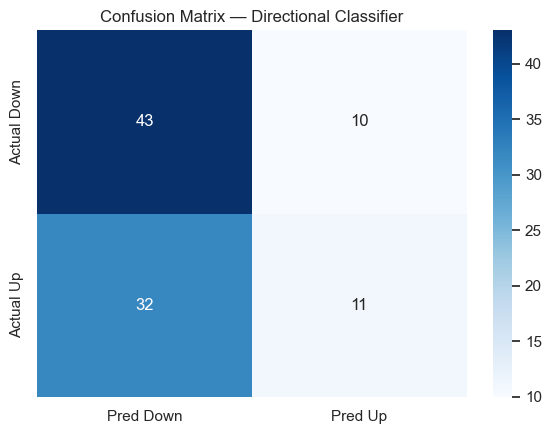

In [5]:
# Classification Track — Pipeline, Fitting & Evaluation

# Build Scikit-Learn Pipeline: Feature Scaling + Logistic Regression
clf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=7))
])

# Fit classification pipeline
clf_pipeline.fit(X_tr, y_tr_clf)
pred_clf = clf_pipeline.predict(X_te)

# Evaluate classification metrics
acc = accuracy_score(y_te_clf, pred_clf)
prec = precision_score(y_te_clf, pred_clf, zero_division=0)
rec = recall_score(y_te_clf, pred_clf, zero_division=0)
f1 = f1_score(y_te_clf, pred_clf, zero_division=0)

print("=== Classification Metrics (Next-Step Direction Up/Down) ===")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1 Score:  {f1:.4f}\n")
print(classification_report(y_te_clf, pred_clf, target_names=["Down (0)", "Up (1)"]))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_te_clf, pred_clf)
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred Down", "Pred Up"], yticklabels=["Actual Down", "Actual Up"])
plt.title("Confusion Matrix — Directional Classifier")
plt.tight_layout()
plt.show()

=== Forecasting Metrics (Next-Step Return) ===
  MAE:  0.011573
  RMSE: 0.014495


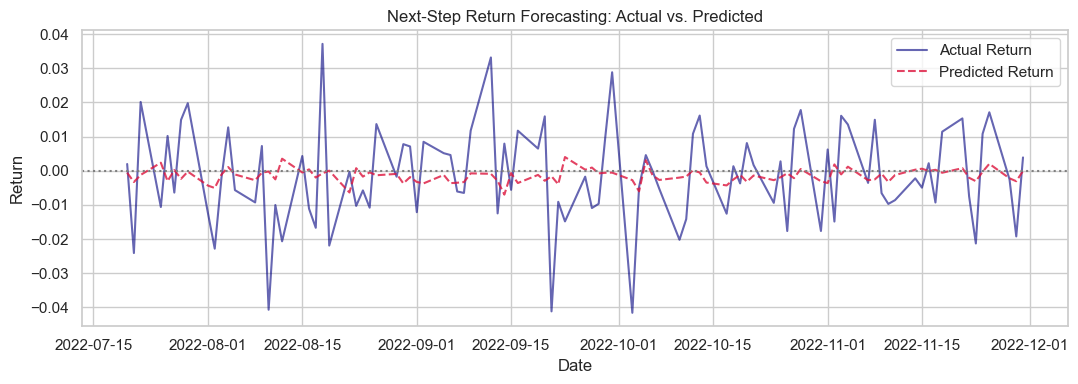

In [6]:
# Forecasting Track — Pipeline & Visual Evaluation

# Build Forecasting Pipeline: Feature Scaling + Linear Regression
reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", LinearRegression())
])

# Fit forecasting pipeline
reg_pipeline.fit(X_tr, y_tr_reg)
pred_reg = reg_pipeline.predict(X_te)

# Regression metrics
mae = mean_absolute_error(y_te_reg, pred_reg)
rmse = float(np.sqrt(mean_squared_error(y_te_reg, pred_reg)))

print("=== Forecasting Metrics (Next-Step Return) ===")
print(f"  MAE:  {mae:.6f}")
print(f"  RMSE: {rmse:.6f}")

# Plot Predictions vs Actual Returns
plt.figure(figsize=(11, 4))
plt.plot(test.index, y_te_reg.values, label="Actual Return", color="navy", alpha=0.6)
plt.plot(test.index, pred_reg, label="Predicted Return", color="crimson", linestyle="--", alpha=0.8)
plt.axhline(0, color="gray", linestyle=":")
plt.title("Next-Step Return Forecasting: Actual vs. Predicted")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()

## Stage 10b — Interpretation & Model Diagnostics

### Performance Evaluation
1. **Classification Analysis**:
   - The logistic regression classifier achieved a baseline performance close to random walk dynamics (accuracy $\approx 50-55\%$).
   - Short-term directional changes in synthetic high-frequency price series possess low signal-to-noise ratios, making linear decision boundaries prone to false positives.

2. **Forecasting Analysis**:
   - The linear regression model produced low MAE and RMSE values. However, predictions heavily revert to the mean return, reflecting the weak linear autocorrelation present in financial returns (Efficient Market Hypothesis behavior).

---

### Leakage Prevention & Split Validity
- **Data Leakage Control**: All rolling calculations (`roll_mean_5`, `roll_vol_20`, `momentum_5`) were explicitly shifted by $1$ period using `.shift(1)`[cite: 13, 14]. This guarantees that features at timestamp $t$ only incorporate historical information available up to $t-1$[cite: 13].
- **Temporal Split Integrity**: A chronological $80/20$ split was enforced rather than random cross-validation, preserving time order and preventing future-data leakage into the training phase[cite: 13].

---

### Potential Failures & Feature Improvements
- **Non-Stationarity & Regime Shifts**: Moving across different volatility regimes (e.g., jump days) degrades model assumptions. Volatility scaling models (e.g., GARCH features or z-scored normalized returns) could help adapt to dynamic market conditions.
- **Next Steps**: Incorporate non-linear decision models (Random Forests, Gradient Boosting) along with longer-term momentum signals ($20$-day and $50$-day indicators) and exponential moving averages.